# Lotto 5/35 Advanced

In [179]:
import time
from datetime import datetime
from typing import List, Optional, Tuple
import csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import itertools
from scipy.stats import norm
from itertools import permutations
import scipy.stats as stats
from tqdm import tqdm

from selenium import webdriver
from selenium.webdriver.chromium.webdriver import ChromiumDriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait, Select
from selenium.webdriver.support import expected_conditions as EC

from bs4 import BeautifulSoup, Tag

## Parameters

## Import libraries

In [180]:
URL = "https://www.minhchinh.com/thong-ke-mega-645"
FROM_DATE = "01-01-2018"  # dd-MM-yyyy
TO_DATE = datetime.now().strftime("%d-%m-%Y")  # dd-MM-yyyy
FROM_DATE, TO_DATE

('01-01-2018', '01-03-2026')

In [181]:
LOTTO_6_45_FILE_NAME = "lotto_6_45"
LOTTO_6_45_CLEANED_FILE_NAME = "lotto_6_45_cleaned"

In [182]:
SCRAPER_BASE_WAIT_TIME = 1

In [183]:
LAST_N_DAY = None

## Helper functions

In [184]:
def update_bs4_parser(web_driver: ChromiumDriver) -> BeautifulSoup:
    return BeautifulSoup(web_driver.page_source, "html.parser")

In [185]:
def navigate_to_url(
    web_driver: ChromiumDriver, url: str
) -> Tuple[ChromiumDriver, BeautifulSoup]:
    print(f'Navigating to URL: "{url}"')
    web_driver.get(url)
    time.sleep(SCRAPER_BASE_WAIT_TIME)
    bs4_parser = update_bs4_parser(web_driver)

    return (web_driver, bs4_parser)

In [186]:
def input_text(web_driver: ChromiumDriver, xpath: str, value: str) -> None:
    input_element = WebDriverWait(web_driver, 10).until(
        EC.element_to_be_clickable((By.XPATH, xpath))
    )
    input_element.clear()
    input_element.send_keys(value)

In [187]:
def click_element(web_driver: ChromiumDriver, xpath: str) -> None:
    element = WebDriverWait(web_driver, 10).until(
        EC.element_to_be_clickable((By.XPATH, xpath))
    )
    element.click()

In [188]:
def extract_table(table: Optional[Tag]):
    # Extract headers
    headers = []
    thead = table.find("thead")
    if thead:
        header_row = thead.find_all("tr")[-1]  # use the last row if rowspan is present
        headers = [th.get_text(strip=True) for th in header_row.find_all("th")]

    # Extract rows
    rows = []
    tbody = table.find("tbody")
    for tr in tbody.find_all("tr"):
        # Skip group title rows
        if tr.get("class") and "group" in tr.get("class"):
            continue
        row = []
        for td in tr.find_all(["td"]):
            text = td.get_text(strip=True)
            row.append(text)
        rows.append(row)

    return (headers, rows)


def extract_table_by_class(
    bs4_parser: BeautifulSoup, class_name: str
) -> Tuple[List, List]:
    table = bs4_parser.find("table", class_=class_name)
    return extract_table(table)

## Start

### Scrape data from web

In [189]:
chrome_options = Options()
chrome_options.add_experimental_option(
    "prefs",
    {
        "profile.managed_default_content_settings.images": 2,  # Disable images
        "profile.managed_default_content_settings.stylesheets": 2,  # Disable CSS
        "profile.managed_default_content_settings.javascript": 1,  # Keep JS if needed
    },
)
chrome_options.add_argument(
    "user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36"
)

In [190]:
web_driver: ChromiumDriver = webdriver.Chrome(options=chrome_options)
bs4_parser: BeautifulSoup = BeautifulSoup(web_driver.page_source, "html.parser")
web_driver.maximize_window()

In [191]:
navigate_to_url(web_driver, URL)

from_date_xpath = '//*[@id="dateFromId"]'
to_date_xpath = '//*[@id="dateToId"]'
submit_button_xpath = '//*[@id="noidung"]/div[2]/div/div[1]/div/button'

click_element(web_driver, from_date_xpath)
input_text(web_driver, from_date_xpath, FROM_DATE)

click_element(web_driver, to_date_xpath)
input_text(web_driver, to_date_xpath, TO_DATE)

click_element(web_driver, submit_button_xpath)

time.sleep(SCRAPER_BASE_WAIT_TIME * 2)

bs4_parser = update_bs4_parser(web_driver)

Navigating to URL: "https://www.minhchinh.com/thong-ke-mega-645"


In [192]:
table_class_name = "table-mini-result"

raw_table = extract_table_by_class(bs4_parser, table_class_name)

if len(raw_table):
    with open(
        f"{LOTTO_6_45_FILE_NAME}.csv", "w", newline="\n", encoding="utf-8"
    ) as file:
        writer = csv.writer(file)
        writer.writerows([raw_table[0]])
        writer.writerows(raw_table[1])

print(f"Data has been saved to '{LOTTO_6_45_FILE_NAME}.csv'")

web_driver.close()

Data has been saved to 'lotto_6_45.csv'


### Preprocess data

In [193]:
pandas_df = pd.read_csv(f"{LOTTO_6_45_FILE_NAME}.csv", dtype=str)

# Extract date and hour
pandas_df["date"] = pandas_df["NgàyMở Thưởng"].str.split().str[0]

# Split 12-digit result into 6 two-digit numbers
for i in range(6):
    col_name = f"x_{i+1}"
    pandas_df[col_name] = pandas_df["Kết Quả"].str[i * 2 : (i + 1) * 2]

# Clean prize (remove commas)
pandas_df["prize"] = pandas_df["Jackpot"].str.replace(",", "", regex=False)

# Keep only new columns
pandas_df = pandas_df[["date", "x_1", "x_2", "x_3", "x_4", "x_5", "x_6", "prize"]]

pandas_df

,date,x_1,x_2,x_3,x_4,x_5,x_6,prize
0,01/03/2026,16,22,23,35,44,45,13545761500
1,27/02/2026,02,04,08,15,17,28,35265228500
2,25/02/2026,04,13,20,22,23,29,32840261000
3,22/02/2026,07,23,24,36,38,40,30192318000
4,20/02/2026,04,25,28,33,34,45,27826445000
...,...,...,...,...,...,...,...,...
1246,12/01/2018,04,08,17,23,27,34,32458724000
1247,10/01/2018,06,18,21,22,37,45,26791424500
1248,07/01/2018,04,06,11,13,24,31,22694481500
1249,05/01/2018,19,30,34,38,42,44,20050529500


In [194]:
pandas_df.to_csv(f"{LOTTO_6_45_CLEANED_FILE_NAME}.csv", index=False)

### Read data

In [195]:
cleaned_df = pd.read_csv(f"{LOTTO_6_45_CLEANED_FILE_NAME}.csv")
cleaned_df

,date,x_1,x_2,x_3,x_4,x_5,x_6,prize
0,01/03/2026,16,22,23,35,44,45,1.354576e+10
1,27/02/2026,2,4,8,15,17,28,3.526523e+10
2,25/02/2026,4,13,20,22,23,29,3.284026e+10
3,22/02/2026,7,23,24,36,38,40,3.019232e+10
4,20/02/2026,4,25,28,33,34,45,2.782644e+10
...,...,...,...,...,...,...,...,...
1246,12/01/2018,4,8,17,23,27,34,3.245872e+10
1247,10/01/2018,6,18,21,22,37,45,2.679142e+10
1248,07/01/2018,4,6,11,13,24,31,2.269448e+10
1249,05/01/2018,19,30,34,38,42,44,2.005053e+10


In [196]:
def make_centered_bins(min_value, n_bins, column_width):
    start = min_value - column_width / 2
    end = min_value + n_bins - 1 + column_width / 2
    return np.arange(start, end + column_width, column_width)


def plot_histograms(cleaned_df, column_width=0.5, mode="percentage"):
    """
    Plots histograms for predefined columns in cleaned_df.

    Parameters:
    - cleaned_df (pd.DataFrame): DataFrame containing the data
    - column_width (float): Width of histogram bins
    - mode (str): "percentage" or "count"
    """

    if mode not in ["percentage", "count"]:
        raise ValueError("mode must be 'percentage' or 'count'")

    columns = ["x_1", "x_2", "x_3", "x_4", "x_5", "x_6"]

    fig, axes = plt.subplots(3, 2, figsize=(30, 15), sharex=False)
    axes = axes.flatten()

    for i, col in enumerate(columns):

        if col not in cleaned_df.columns:
            raise ValueError(f"Column '{col}' not found in DataFrame")

        data = cleaned_df[col].astype(int)

        # Choose bin range
        bins = make_centered_bins(1, 45, column_width)
        xticks = range(1, 46)

        # Apply weights only if percentage mode
        if mode == "percentage":
            weights = np.ones_like(data) * 100.0 / len(data)
            axes[i].hist(data, bins=bins, weights=weights)
            axes[i].set_ylabel("Percentage (%)")
        else:
            axes[i].hist(data, bins=bins)
            axes[i].set_ylabel("Count")

        axes[i].set_xticks(xticks)
        axes[i].set_title(col)
        axes[i].tick_params(axis="x", bottom=True, labelbottom=True)

    plt.tight_layout()
    plt.show()


def extended_summary(series):
    summary = {
        "Count": series.count(),
        "Mean": series.mean(),
        "Median": series.median(),
        "Mode": series.mode().iloc[0] if not series.mode().empty else None,
        "Std Dev": series.std(),
        "Variance": series.var(),
        "Min": series.min(),
        "Max": series.max(),
        "Skewness": series.skew(),
        "Kurtosis": series.kurt(),
        "Unique Values": series.nunique(),
    }

    return pd.DataFrame(summary, index=[series.name]).T

### Plot charts

In [197]:
# Plot config
plt.style.use("fivethirtyeight")
plt.rcParams["figure.figsize"] = (14, 6)
column_width = 0.5

In [198]:
cleaned_df

,date,x_1,x_2,x_3,x_4,x_5,x_6,prize
0,01/03/2026,16,22,23,35,44,45,1.354576e+10
1,27/02/2026,2,4,8,15,17,28,3.526523e+10
2,25/02/2026,4,13,20,22,23,29,3.284026e+10
3,22/02/2026,7,23,24,36,38,40,3.019232e+10
4,20/02/2026,4,25,28,33,34,45,2.782644e+10
...,...,...,...,...,...,...,...,...
1246,12/01/2018,4,8,17,23,27,34,3.245872e+10
1247,10/01/2018,6,18,21,22,37,45,2.679142e+10
1248,07/01/2018,4,6,11,13,24,31,2.269448e+10
1249,05/01/2018,19,30,34,38,42,44,2.005053e+10


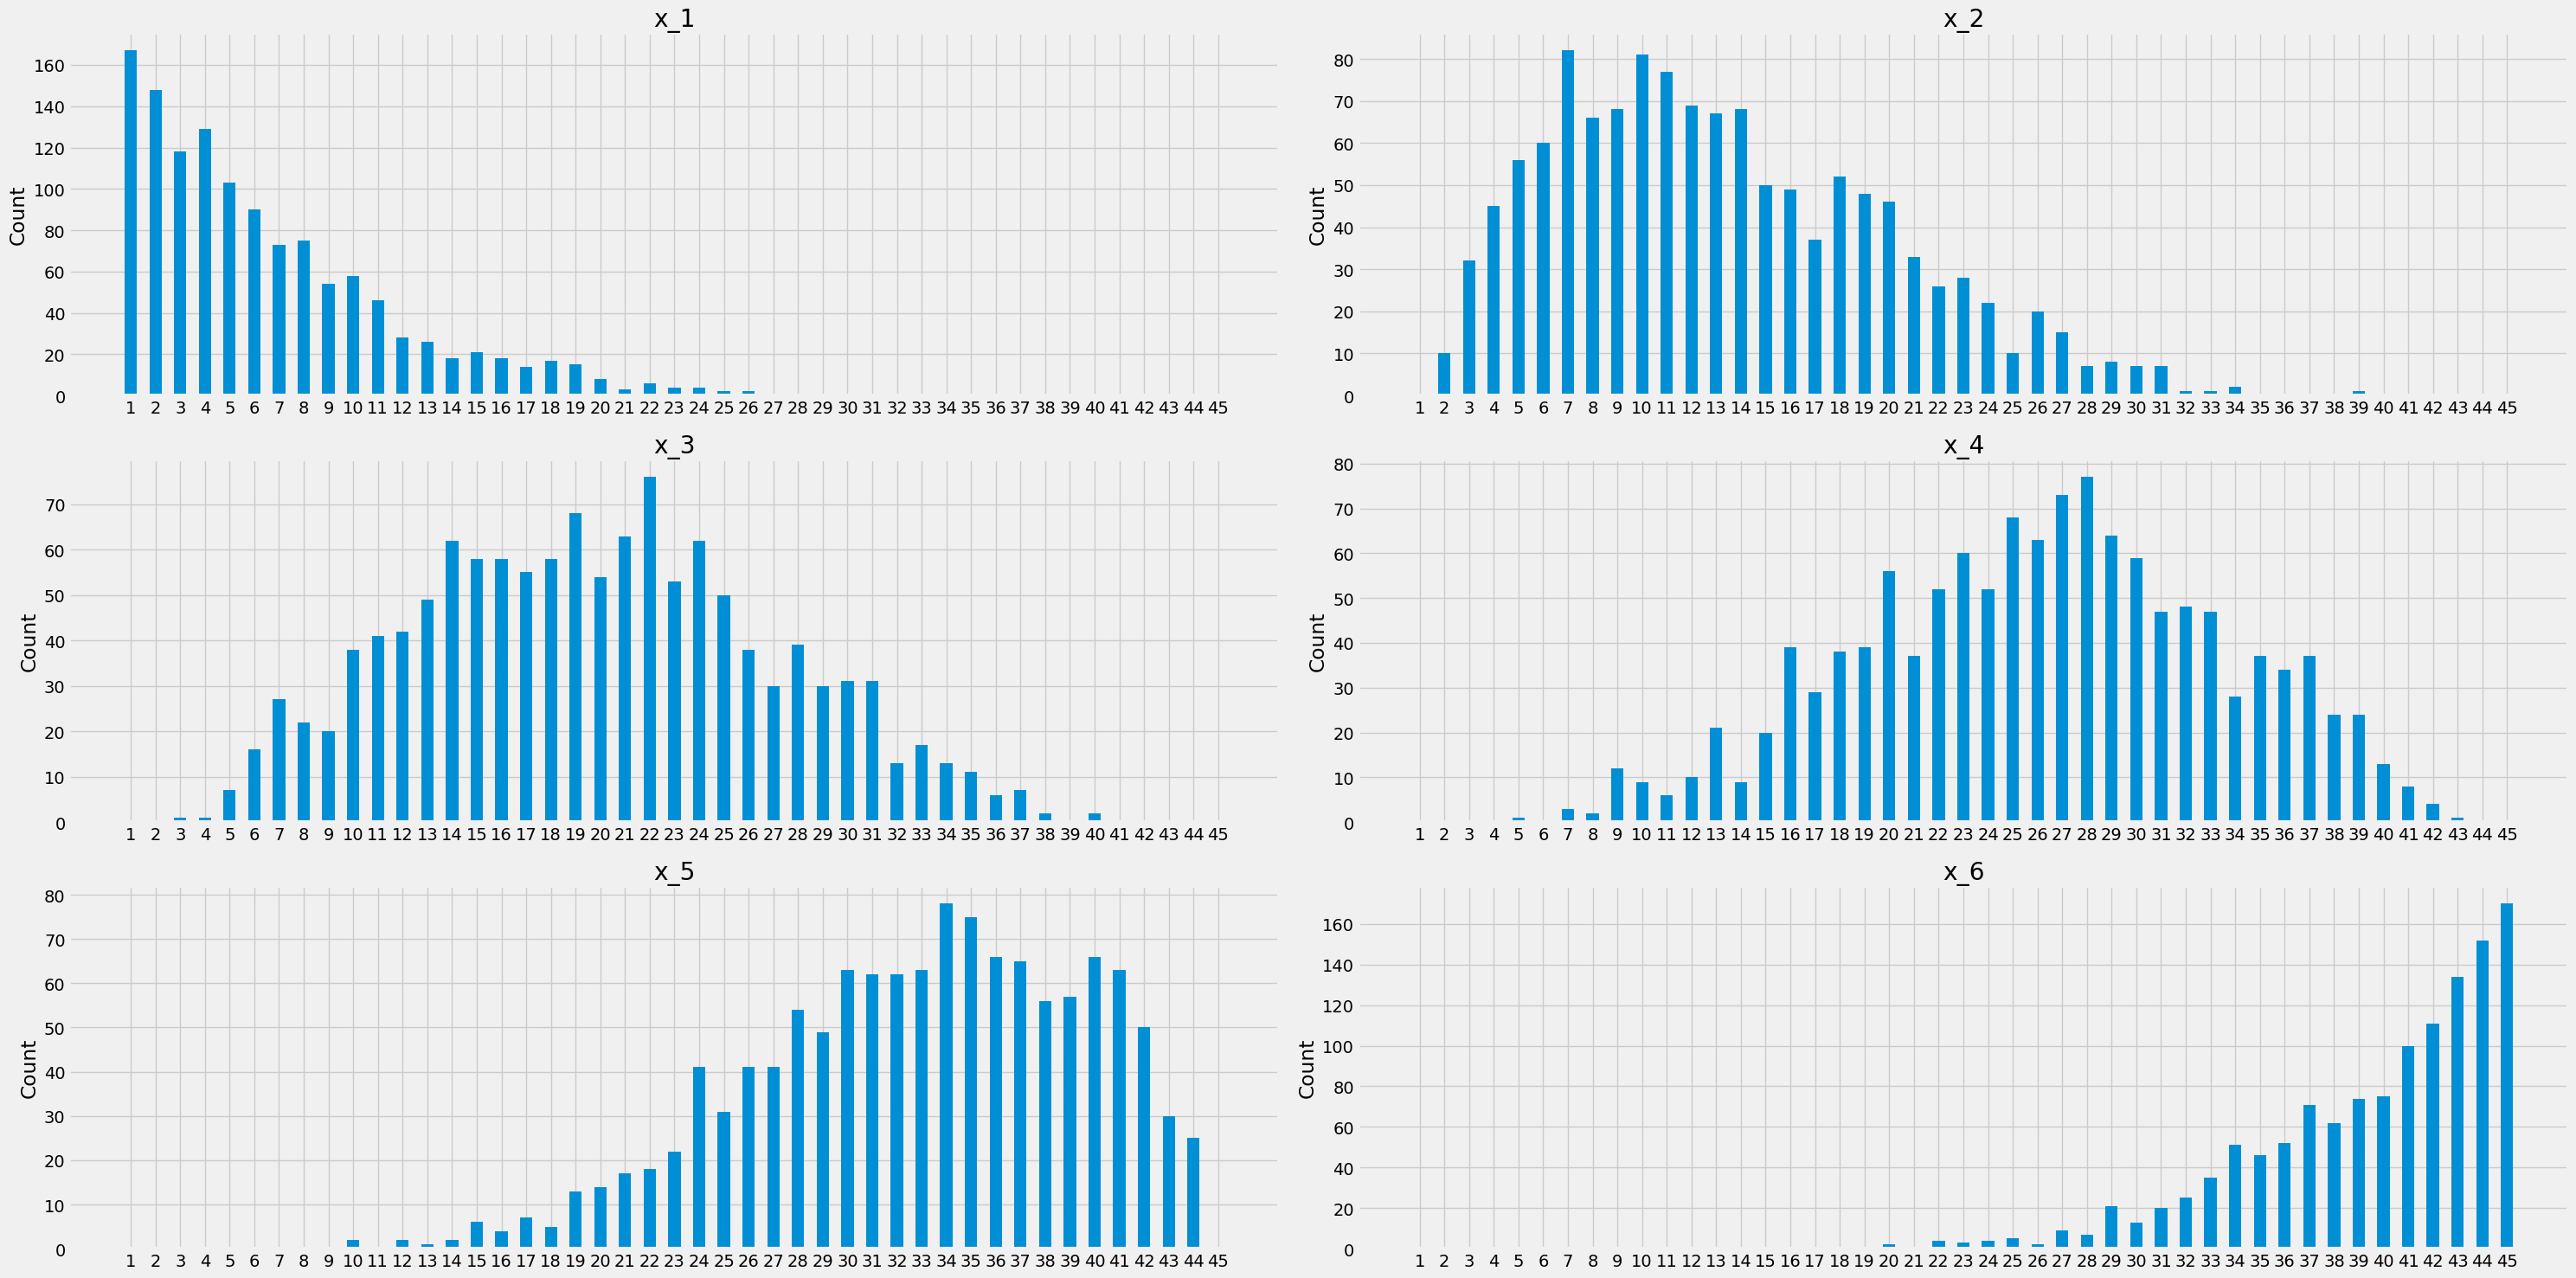

In [199]:
plot_histograms(cleaned_df, mode="count")

### Analysis data

#### Helper function

In [200]:
def plot_dictionary(data, color=None, title="Dictionary Values"):
    x = sorted(data.keys())
    y = [data[k] for k in x]

    plt.figure(figsize=(20, 6))
    plt.bar(x, y, color=color if color else None)

    plt.xlabel("Ball Number")
    plt.ylabel("Possibility")
    plt.title(title)

    plt.xticks(x)
    plt.ylim(0, 1)  # set y-axis range from 0 to 1
    plt.grid(True, axis="y", linestyle="--", alpha=0.5)

    plt.show()

In [208]:
def fit_and_select_distribution(
    data,
    distributions=["geometric", "normal", "beta", "poisson", "exponential"],
    index_range=(1, 45),
):
    data = np.array(data)
    total_observations = len(data)

    if total_observations == 0:
        return None

    x_min, x_max = index_range
    x_vals = np.arange(x_min, x_max + 1)

    observed_counts = np.array([np.sum(data == x) for x in x_vals])

    best_log_likelihood = -np.inf
    best_distribution = None
    best_expected_probs = None

    for distribution in distributions:
        try:

            if distribution == "geometric":
                mean_x = np.mean(data)
                if mean_x <= 0:
                    continue
                p_hat = 1 / mean_x
                expected_probs = stats.geom.pmf(x_vals, p_hat)

            elif distribution == "normal":
                mean_x = np.mean(data)
                std_x = np.std(data, ddof=0)
                expected_probs = stats.norm.cdf(
                    x_vals + 0.5, mean_x, std_x
                ) - stats.norm.cdf(x_vals - 0.5, mean_x, std_x)

            elif distribution == "beta":
                min_val = data.min()
                max_val = data.max()
                scale_range = max_val - min_val
                if scale_range == 0:
                    continue

                data_scaled = (data - min_val) / scale_range
                a, b, _, _ = stats.beta.fit(data_scaled, floc=0, fscale=1)

                x_low = (x_vals - 0.5 - min_val) / scale_range
                x_high = (x_vals + 0.5 - min_val) / scale_range

                x_low = np.clip(x_low, 0, 1)
                x_high = np.clip(x_high, 0, 1)

                expected_probs = stats.beta.cdf(x_high, a, b) - stats.beta.cdf(
                    x_low, a, b
                )

            elif distribution == "poisson":
                lambda_hat = np.mean(data)
                expected_probs = stats.poisson.pmf(x_vals, lambda_hat)

            elif distribution == "exponential":
                loc, scale = stats.expon.fit(data)
                expected_probs = stats.expon.cdf(
                    x_vals + 0.5, loc, scale
                ) - stats.expon.cdf(x_vals - 0.5, loc, scale)

            else:
                continue

            if expected_probs.sum() == 0:
                continue

            expected_probs = expected_probs / expected_probs.sum()

            log_likelihood = np.sum(observed_counts * np.log(expected_probs + 1e-12))

            if log_likelihood > best_log_likelihood:
                best_log_likelihood = log_likelihood
                best_distribution = distribution
                best_expected_probs = expected_probs

        except:
            continue

    return {
        "x_vals": x_vals,
        "best_distribution": best_distribution,
        "expected_probs": best_expected_probs,
    }

#### Setting

In [209]:
# plot_dictionary(MAIN_POSSIBILITY_TABLE, title="Main Possibility Table")

In [210]:
# plot_dictionary(SPECIAL_POSSIBILITY_TABLE, title="Special Possibility Table")

In [211]:
SETTINGS = {
    "x_1": {"n_highest": 45},
    "x_2": {"n_highest": 45},
    "x_3": {"n_highest": 45},
    "x_4": {"n_highest": 45},
    "x_5": {"n_highest": 45},
    "x_6": {"n_highest": 45},
}

In [212]:
ORIGINAL_PERMUTATIONS = [key for key in SETTINGS.keys() if key != "x_s"]
ORIGINAL_PERMUTATIONS

['x_1', 'x_2', 'x_3', 'x_4', 'x_5', 'x_6']

In [213]:
ALL_PERMUTATIONS = list(permutations(ORIGINAL_PERMUTATIONS))
len(ALL_PERMUTATIONS)

720

#### For loop

In [214]:
MAIN_POSSIBILITY_TABLE = pd.DataFrame(
    0.0,
    index=range(1, 46),
    columns=["x_1", "x_2", "x_3", "x_4", "x_5", "x_6"],
)

total_joint_weight = 0.0

for per in tqdm(ALL_PERMUTATIONS, desc="Processing permutations"):

    transform_df = cleaned_df.copy()

    if LAST_N_DAY is not None:
        transform_df = transform_df.iloc[:LAST_N_DAY, :]

    joint_probability_weight = 1.0

    for ball_column in per:

        if len(transform_df) == 0:
            break

        hist_data = np.bincount(
            transform_df[ball_column].values,
            minlength=46
        )[1:]

        total_observations = hist_data.sum()
        if total_observations == 0:
            break

        # Create expanded data for MLE
        data = np.repeat(np.arange(1, 46), hist_data)

        fit_result = fit_and_select_distribution(data)
        if fit_result is None:
            break

        expected_probs = fit_result["expected_probs"]

        # TRUE probability distribution
        conditional_probs = expected_probs

        # Select top-N
        n_highest_threshold = SETTINGS[ball_column]["n_highest"]
        top_indices = np.argsort(conditional_probs)[-n_highest_threshold:]

        selected_probs = conditional_probs[top_indices]
        stage_probability = selected_probs.sum()

        joint_probability_weight *= stage_probability

        # Accumulate weighted probabilities
        for idx in top_indices:
            ball_number = idx + 1
            MAIN_POSSIBILITY_TABLE.loc[
                ball_number, ball_column
            ] += (
                conditional_probs[idx] * joint_probability_weight
            )

        # Condition dataset
        final_balls = (top_indices + 1).tolist()
        transform_df = transform_df[
            transform_df[ball_column].isin(final_balls)
        ]

    total_joint_weight += joint_probability_weight

if total_joint_weight > 0:
    MAIN_POSSIBILITY_TABLE /= total_joint_weight

Processing permutations: 100%|██████████| 720/720 [00:13<00:00, 55.28it/s]


#### Plot MAIN_POSSIBILITY_TABLE

In [215]:
MAIN_POSSIBILITY_TABLE

,x_1,x_2,x_3,x_4,x_5,x_6
1,0.152798,1.152278e-02,0.001929,0.000146,6.679298e-07,1.420281e-14
2,0.129464,1.499126e-02,0.002733,0.000231,1.354021e-06,6.426002e-14
3,0.109694,1.907047e-02,0.003799,0.000360,2.683678e-06,2.794316e-13
4,0.092943,2.372067e-02,0.005181,0.000551,5.200511e-06,1.167828e-12
5,0.078749,2.884926e-02,0.006932,0.000827,9.853086e-06,4.690841e-12
6,0.066723,3.430715e-02,0.009100,0.001218,1.825195e-05,1.810888e-11
7,0.056534,3.989118e-02,0.011720,0.001760,3.305650e-05,6.718959e-11
8,0.047901,4.535356e-02,0.014809,0.002497,5.853494e-05,2.395973e-10
9,0.040586,5.041829e-02,0.018358,0.003477,1.013408e-04,8.211671e-10
10,0.034388,5.480335e-02,0.022327,0.004752,1.715395e-04,2.704900e-09


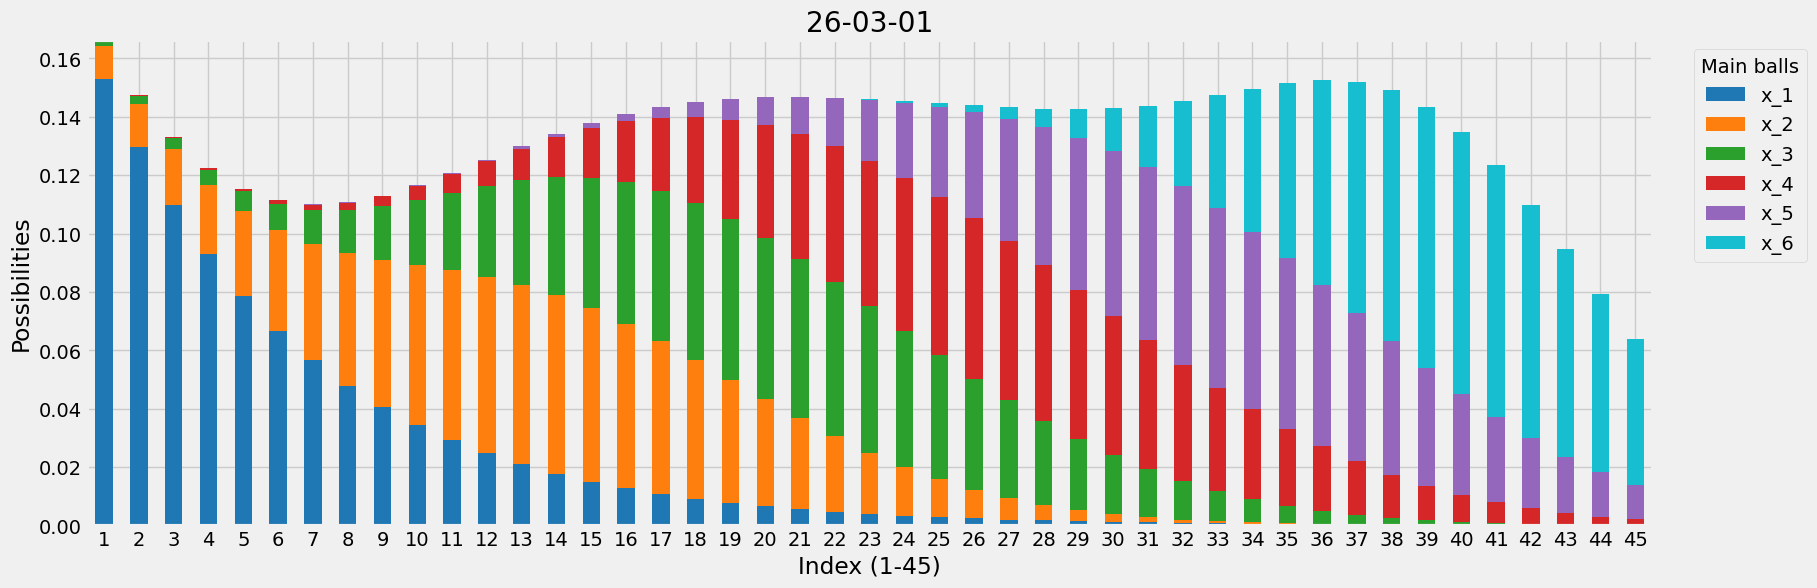

In [229]:
colors = [
    "#1F77B4",  # Blue
    "#FF7F0E",  # Orange
    "#2CA02C",  # Green
    "#D62728",  # Red
    "#9467BD",  # Purple
    "#17BECF",  # Teal
]

ax = MAIN_POSSIBILITY_TABLE.plot(
    kind="bar", stacked=True, figsize=(18, 6), color=colors
)

ax.set_xlabel("Index (1-45)")
ax.set_ylabel("Possibilities")
ax.set_xticks(range(45))
ax.set_xticklabels(range(1, 46), rotation=0)

plt.legend(title="Main balls", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.title(
    f"{datetime.now().strftime('%y-%m-%d')}"
    f"{f' - Last {LAST_N_DAY} days' if LAST_N_DAY is not None else ''}"
)
plt.show()

### Create result permutations

In [230]:
def create_ordered_permutations(ranges_dict):
    # Separate ordered columns
    ordered_keys = list(ranges_dict.keys())
    ordered_values = list(ranges_dict.values())

    # Step 1: Generate strictly increasing combinations
    ordered_permutations = [
        p
        for p in itertools.product(*ordered_values)
        if all(p[i] < p[i + 1] for i in range(len(p) - 1))
    ]

    return pd.DataFrame(ordered_permutations, columns=ordered_keys)

In [231]:
ranges = {
    "x_1": MAIN_POSSIBILITY_TABLE["x_1"].nlargest(2).index,
    "x_2": MAIN_POSSIBILITY_TABLE["x_2"].nlargest(2).index,
    "x_3": MAIN_POSSIBILITY_TABLE["x_3"].nlargest(2).index,
    "x_4": MAIN_POSSIBILITY_TABLE["x_4"].nlargest(2).index,
    "x_5": MAIN_POSSIBILITY_TABLE["x_5"].nlargest(2).index,
    "x_6": MAIN_POSSIBILITY_TABLE["x_6"].nlargest(2).index,
}

In [232]:
output_df = create_ordered_permutations(ranges)
output_df

,x_1,x_2,x_3,x_4,x_5,x_6
0,1,13,20,26,33,40
1,1,13,20,26,33,39
2,1,13,20,26,32,40
3,1,13,20,26,32,39
4,1,13,20,27,33,40
...,...,...,...,...,...,...
59,2,14,19,26,32,39
60,2,14,19,27,33,40
61,2,14,19,27,33,39
62,2,14,19,27,32,40


In [233]:
output_df.to_csv(f"lotto_6_45_permutations_advanced.csv", index=False, header=True)

In [234]:
df_a = cleaned_df.copy()
df_b = pd.DataFrame(output_df[["x_1", "x_2", "x_3", "x_4", "x_5", "x_6"]])

In [235]:
df_a

,date,x_1,x_2,x_3,x_4,x_5,x_6,prize
0,01/03/2026,16,22,23,35,44,45,1.354576e+10
1,27/02/2026,2,4,8,15,17,28,3.526523e+10
2,25/02/2026,4,13,20,22,23,29,3.284026e+10
3,22/02/2026,7,23,24,36,38,40,3.019232e+10
4,20/02/2026,4,25,28,33,34,45,2.782644e+10
...,...,...,...,...,...,...,...,...
1246,12/01/2018,4,8,17,23,27,34,3.245872e+10
1247,10/01/2018,6,18,21,22,37,45,2.679142e+10
1248,07/01/2018,4,6,11,13,24,31,2.269448e+10
1249,05/01/2018,19,30,34,38,42,44,2.005053e+10


In [236]:
# identify rows that are exact duplicates of a previous row
dup_rows = df_a[df_a.duplicated()]
dup_rows

,date,x_1,x_2,x_3,x_4,x_5,x_6,prize


In [237]:
df_b

,x_1,x_2,x_3,x_4,x_5,x_6
0,1,13,20,26,33,40
1,1,13,20,26,33,39
2,1,13,20,26,32,40
3,1,13,20,26,32,39
4,1,13,20,27,33,40
...,...,...,...,...,...,...
59,2,14,19,26,32,39
60,2,14,19,27,33,40
61,2,14,19,27,33,39
62,2,14,19,27,32,40


In [238]:
common_rows = pd.merge(df_a, df_b)

common_rows

,date,x_1,x_2,x_3,x_4,x_5,x_6,prize


In [239]:
print("Existed: ", len(common_rows))
print("Existed percentage: ", len(common_rows) / len(df_a) * 100)

Existed:  0
Existed percentage:  0.0


In [240]:
check = [16, 22, 23, 35, 44, 45]
mask = (
    (cleaned_df["x_1"] == check[0])
    & (cleaned_df["x_2"] == check[1])
    & (cleaned_df["x_3"] == check[2])
    & (cleaned_df["x_4"] == check[3])
    & (cleaned_df["x_5"] == check[4])
    & (cleaned_df["x_6"] == check[5])
)
matching_rows = cleaned_df[mask]
matching_rows

,date,x_1,x_2,x_3,x_4,x_5,x_6,prize
0,01/03/2026,16,22,23,35,44,45,1.354576e+10
